In [1]:
import pandas as pd
import numpy as np

apps = pd.read_csv("Play Store Data.csv")
reviews = pd.read_csv("User Reviews.csv")
print("Apps Shape:", apps.shape)
print("Reviews Shape:", reviews.shape)

Apps Shape: (10841, 13)
Reviews Shape: (64295, 5)


In [2]:
apps = apps[apps['Installs'].notna()]
apps = apps[apps['Installs'] != 'Free']
apps['Installs'] = apps['Installs'].str.replace('+','', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',','', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')
apps = apps.dropna(subset=['Installs'])
apps['Installs'] = apps['Installs'].astype(int)

In [3]:
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')
apps = apps.dropna(subset=['Reviews'])
apps['Reviews'] = apps['Reviews'].astype(int)

In [4]:
apps['Price'] = apps['Price'].str.replace('$','', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce').fillna(0)

In [5]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    if size == 'Varies with device':
        return np.nan
    if 'M' in size:
        return float(size.replace('M',''))
    if 'k' in size:
        return float(size.replace('k','')) / 1024
    return np.nan

apps['Size_MB'] = apps['Size'].apply(convert_size)

In [6]:
apps['Last Updated'] = pd.to_datetime(apps['Last Updated'], errors='coerce')
apps['Month'] = apps['Last Updated'].dt.to_period('M')

In [7]:
def clean_android(ver):
    if isinstance(ver, str):
        return ver.split()[0]
    return np.nan

apps['Android Ver'] = apps['Android Ver'].apply(clean_android)
apps['Android Ver'] = pd.to_numeric(apps['Android Ver'], errors='coerce')

In [8]:
apps['Revenue'] = apps['Installs'] * apps['Price']

In [9]:
reviews = reviews.dropna(subset=['Sentiment_Subjectivity'])
reviews_grouped = (
    reviews.groupby('App')['Sentiment_Subjectivity']
    .mean()
    .reset_index()
)

In [10]:
final_df = pd.merge(apps, reviews_grouped, on='App', how='left')

print("Final Shape:", final_df.shape)

Final Shape: (10840, 17)


In [11]:
final_df['has_S'] = final_df['App'].str.contains('S', case=False, na=False)
final_df['has_number'] = final_df['App'].str.contains(r'\d', regex=True)
final_df['category_start_letter'] = final_df['Category'].str[0]

In [12]:
final_df.to_csv("cleaned_data.csv", index=False)

In [13]:
final_df.info()
final_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   App                     10840 non-null  object        
 1   Category                10840 non-null  object        
 2   Rating                  9366 non-null   float64       
 3   Reviews                 10840 non-null  int64         
 4   Size                    10840 non-null  object        
 5   Installs                10840 non-null  int64         
 6   Type                    10839 non-null  object        
 7   Price                   10840 non-null  float64       
 8   Content Rating          10840 non-null  object        
 9   Genres                  10840 non-null  object        
 10  Last Updated            10840 non-null  datetime64[ns]
 11  Current Ver             10832 non-null  object        
 12  Android Ver             7673 non-null   float6

,Rating,Reviews,Installs,Price,Last Updated,Android Ver,Size_MB,Revenue,Sentiment_Subjectivity
count,9366.000000,1.084000e+04,1.084000e+04,10840.000000,10840,7673.000000,9145.000000,1.084000e+04,1229.000000
mean,4.191757,4.441529e+05,1.546434e+07,1.027368,2017-11-21 06:43:02.435424256,3.898527,21.516165,3.585142e+04,0.493178
min,1.000000,0.000000e+00,0.000000e+00,0.000000,2010-05-21 00:00:00,1.000000,0.008301,0.000000e+00,0.000000
25%,4.000000,3.800000e+01,1.000000e+03,0.000000,2017-09-20 00:00:00,4.000000,4.900000,0.000000e+00,0.458403
50%,4.300000,2.094000e+03,1.000000e+05,0.000000,2018-05-24 00:00:00,4.100000,13.000000,0.000000e+00,0.498398
75%,4.500000,5.477550e+04,5.000000e+06,0.000000,2018-07-20 00:00:00,4.300000,30.000000,0.000000e+00,0.534886
max,5.000000,7.815831e+07,1.000000e+09,400.000000,2018-08-08 00:00:00,8.000000,100.000000,6.990000e+07,0.916667
std,0.515219,2.927761e+06,8.502936e+07,15.949703,NaN,0.876864,22.589084,1.065980e+06,0.079069


In [14]:
final_df = final_df[final_df['Installs'] > 0]

In [15]:
final_df = final_df.dropna(subset=['Rating'])

In [16]:
print(final_df.shape)
print(final_df.isnull().mean() * 100)

(9366, 20)
App                        0.000000
Category                   0.000000
Rating                     0.000000
Reviews                    0.000000
Size                       0.000000
Installs                   0.000000
Type                       0.000000
Price                      0.000000
Content Rating             0.000000
Genres                     0.000000
Last Updated               0.000000
Current Ver                0.042708
Android Ver               30.066197
Size_MB                   17.478112
Month                      0.000000
Revenue                    0.000000
Sentiment_Subjectivity    86.888747
has_S                      0.000000
has_number                 0.000000
category_start_letter      0.000000
dtype: float64


In [17]:
monthly_installs = (
    final_df.groupby(['Month','Category'])['Installs']
    .sum()
    .reset_index()
)

monthly_installs = monthly_installs.sort_values(['Category','Month'])

monthly_installs['MoM_Growth'] = (
    monthly_installs.groupby('Category')['Installs']
    .pct_change()
)

monthly_installs.head()

,Month,Category,Installs,MoM_Growth
599,2017-03,ART_AND_DESIGN,50000,NaN
642,2017-05,ART_AND_DESIGN,50000,0.0
708,2017-08,ART_AND_DESIGN,100000,1.0
735,2017-09,ART_AND_DESIGN,1000000,9.0
758,2017-10,ART_AND_DESIGN,1500000,0.5


In [18]:
print(final_df['Category'].unique())

['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION']


Task 1


In [19]:
task1_categories = [
    'GAME','BEAUTY','BUSINESS','COMICS','COMMUNICATION',
    'DATING','ENTERTAINMENT','SOCIAL','EVENTS'
]

df_task1 = final_df[
    (final_df['Rating'] > 3.5) &
    (final_df['Category'].isin(task1_categories)) &
    (final_df['Reviews'] > 500) &
    (final_df['has_S'] == False) &
    (final_df['Sentiment_Subjectivity'] > 0.5) &
    (final_df['Installs'] > 50000)
]

print("Task 1 Filtered Shape:", df_task1.shape)

Task 1 Filtered Shape: (50, 20)


In [20]:
print(df_task1[['App','Category','Rating','Size_MB','Installs','Sentiment_Subjectivity']].head())

print("Missing Size_MB:", df_task1['Size_MB'].isnull().sum())

               App       Category  Rating  Size_MB  Installs  \
198  Google Primer       BUSINESS     4.4     18.0  10000000   
206   Call Blocker       BUSINESS     4.6      3.2   5000000   
360     Chrome Dev  COMMUNICATION     4.4      NaN   5000000   
376       GMX Mail  COMMUNICATION     4.3      NaN  10000000   
404        GroupMe  COMMUNICATION     4.5      NaN  10000000   

     Sentiment_Subjectivity  
198                0.675000  
206                0.655431  
360                0.520779  
376                0.540740  
404                0.518137  
Missing Size_MB: 7


In [21]:
df_task1 = df_task1.dropna(subset=['Size_MB'])

In [22]:
print(df_task1[['App','Category','Rating','Size_MB','Installs','Sentiment_Subjectivity']].head())

print("Missing Size_MB:", df_task1['Size_MB'].isnull().sum())

                                                   App       Category  Rating  \
198                                      Google Primer       BUSINESS     4.4   
206                                       Call Blocker       BUSINESS     4.6   
436                                       Call Blocker  COMMUNICATION     4.1   
440  CallApp: Caller ID, Blocker & Phone Call Recorder  COMMUNICATION     4.4   
450                                        Caller ID +  COMMUNICATION     4.0   

       Size_MB  Installs  Sentiment_Subjectivity  
198  18.000000  10000000                0.675000  
206   3.200000   5000000                0.655431  
436  10.000000   1000000                0.655431  
440  20.000000  10000000                0.506481  
450   0.115234   1000000                0.600000  
Missing Size_MB: 0


In [23]:
translation_map = {
    'BEAUTY': 'सौंदर्य',      # Hindi
    'BUSINESS': 'வணிகம்',    # Tamil
    'DATING': 'Partnersuche' # German
}

df_task1['Category_Translated'] = df_task1['Category'].replace(translation_map)

In [24]:
print(df_task1[['Category','Category_Translated']].drop_duplicates())

           Category Category_Translated
198        BUSINESS              வணிகம்
436   COMMUNICATION       COMMUNICATION
485          DATING        Partnersuche
886   ENTERTAINMENT       ENTERTAINMENT
1664           GAME                GAME
2600         SOCIAL              SOCIAL


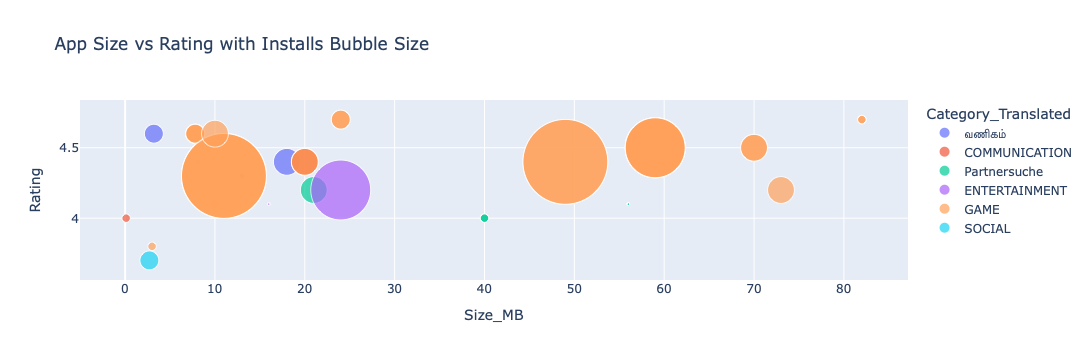

In [25]:
import plotly.express as px

fig = px.scatter(
    df_task1,
    x='Size_MB',
    y='Rating',
    size='Installs',
    color='Category_Translated',
    hover_name='App',
    size_max=60,
    title="App Size vs Rating with Installs Bubble Size"
)

fig.show()

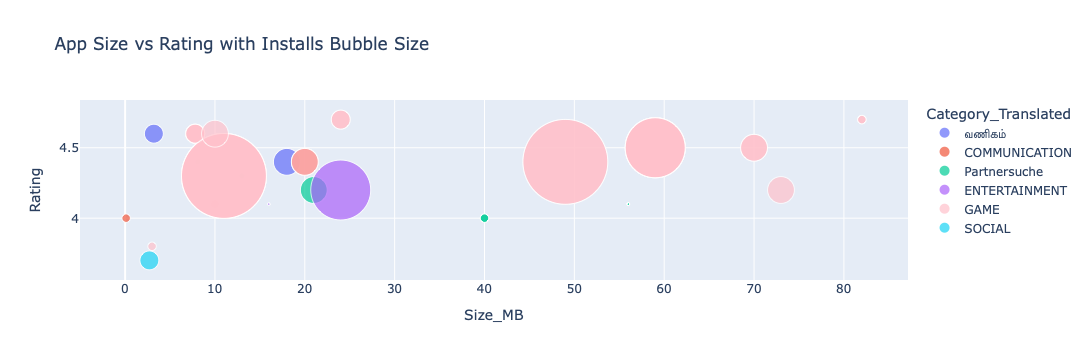

In [26]:
fig.for_each_trace(
    lambda trace: trace.update(marker=dict(color='pink'))
    if trace.name == 'GAME' else None
)

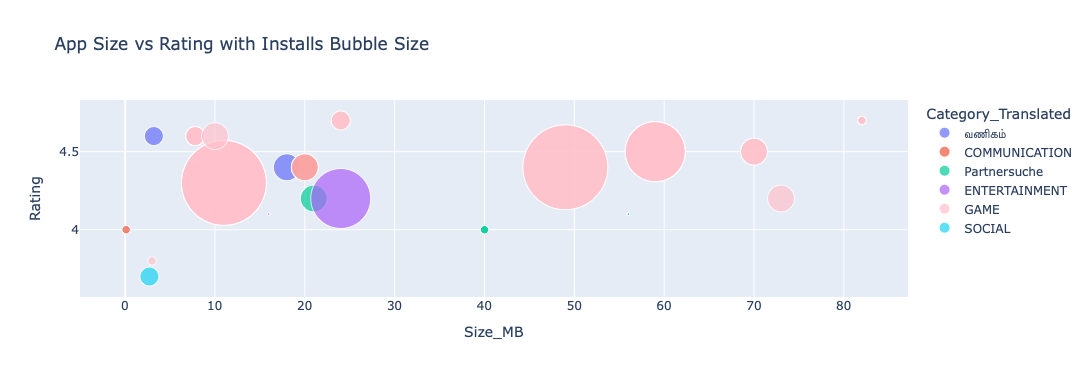

In [27]:
fig.show()

In [28]:
fig.write_html("task1_bubble_chart.html")

In [29]:
df_task1[df_task1['Category']=='BEAUTY']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,...,Current Ver,Android Ver,Size_MB,Month,Revenue,Sentiment_Subjectivity,has_S,has_number,category_start_letter,Category_Translated


In [30]:
for trace in fig.data:
    if "GAME" in trace.name:
        trace.marker.color = "pink"

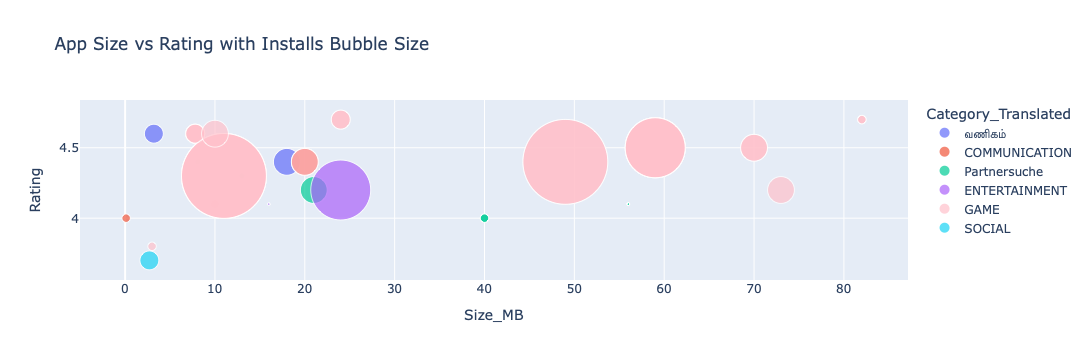

In [31]:
fig.update_traces(marker=dict(opacity=0.7))

In [32]:
fig.write_html("task1_bubble_chart.html")

TASK 2


In [33]:
restricted_letters = ['A','C','G','S']
df_task2 = final_df[~final_df['Category'].str.startswith(tuple(restricted_letters))]

In [34]:
category_installs = (df_task2.groupby('Category')['Installs'].sum().reset_index())

In [35]:
top5_categories = category_installs.nlargest(5,'Installs')
print(top5_categories)
top5_categories['Highlight'] = top5_categories['Installs'] > 1000000

              Category     Installs
20        PRODUCTIVITY  14176070180
21               TOOLS  11450724500
7               FAMILY  10257701590
19         PHOTOGRAPHY  10088243130
16  NEWS_AND_MAGAZINES   7496210650


In [36]:
country_map = {
    top5_categories.iloc[0]['Category']:'USA',
    top5_categories.iloc[1]['Category']:'India',
    top5_categories.iloc[2]['Category']:'Brazil',
    top5_categories.iloc[3]['Category']:'Germany',
    top5_categories.iloc[4]['Category']:'Australia'
}
top5_categories['Country'] = top5_categories['Category'].map(country_map)

/var/folders/wb/77r3wmyx17jb3jym31pfs8pc0000gn/T/ipykernel_7176/3343881775.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



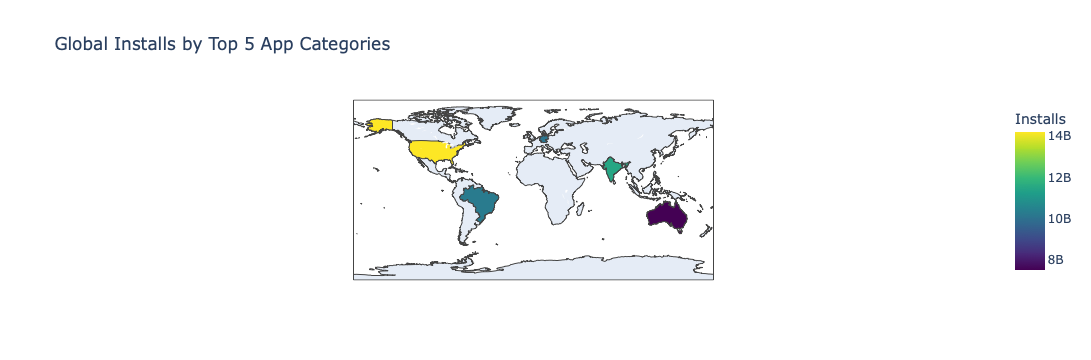

In [37]:
fig = px.choropleth(
    top5_categories,
    locations="Country",
    locationmode="country names",
    color="Installs",
    hover_name="Category",
    color_continuous_scale="Viridis",
    title="Global Installs by Top 5 App Categories"
)
fig.show()

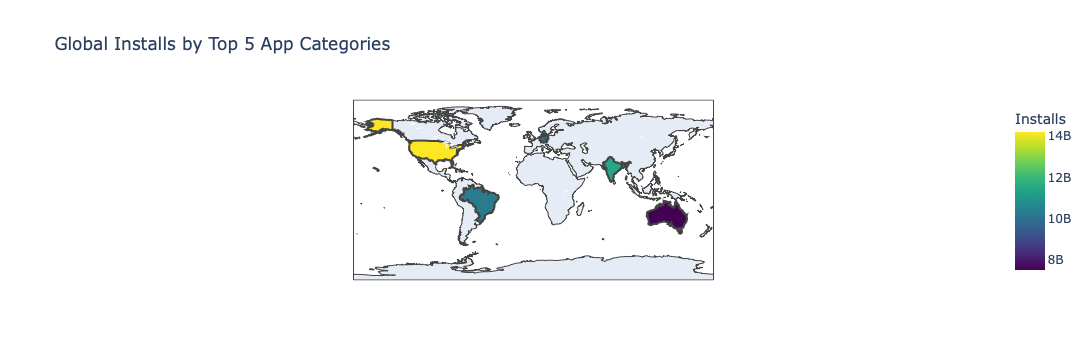

In [38]:
fig.update_traces(marker_line_width=2)

In [39]:
fig.write_html("task2_choropleth_map.html")

Task 3

In [40]:
df_task3 = final_df[
    (final_df['Reviews'] > 500)&(~final_df['App'].str.startswith(('X','Y','Z')))&(~final_df['has_S'])&(final_df['Category'].str.startswith(('E','C','B')))]

print("Task 3 dataset shape:", df_task3.shape)

Task 3 dataset shape: (244, 20)


In [41]:
translation_map = {
    'BEAUTY': 'सौंदर्य',
    'BUSINESS': 'வணிகம்',
    'DATING': 'Partnersuche'
}
df_task3['Category_Translated'] = df_task3['Category'].replace(translation_map)

/var/folders/wb/77r3wmyx17jb3jym31pfs8pc0000gn/T/ipykernel_7176/775640012.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [42]:
time_series = (
    df_task3.groupby(['Month','Category_Translated'])['Installs'].sum().reset_index())
time_series = time_series.sort_values(['Category_Translated','Month'])

In [43]:
time_series['MoM_Growth'] = (time_series.groupby('Category_Translated')['Installs'].pct_change())
time_series['High_Growth'] = time_series['MoM_Growth'] > 0.20

In [44]:
time_series['Month'] = time_series['Month'].astype(str)

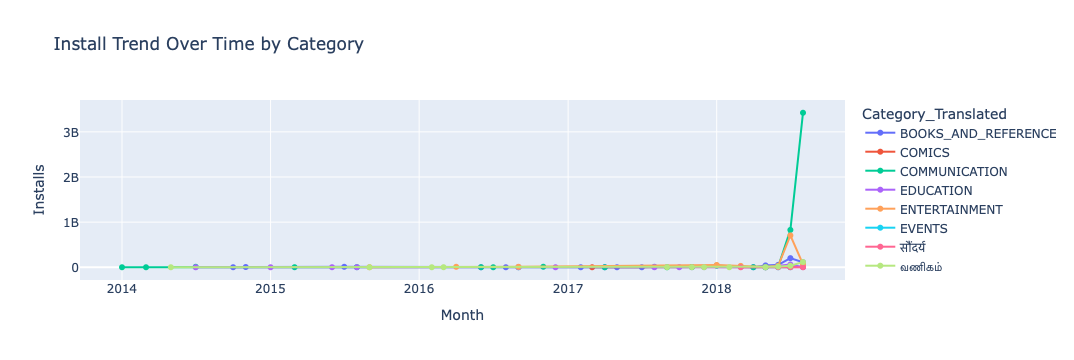

In [45]:
fig = px.line(
    time_series,
    x='Month',
    y='Installs',
    color='Category_Translated',
    title="Install Trend Over Time by Category"
)
fig.update_traces(mode="lines+markers")
fig.show()

In [46]:
fig.write_html("task3_timeseries_chart.html")

Task 4


In [47]:
df_task4 = final_df[(final_df['Rating'] >= 4.2)&(final_df['Reviews']>1000)&(~final_df['has_number'])&(final_df['Category'].str.startswith(('T','P')))&(final_df['Size_MB'] >= 20)&(final_df['Size_MB']<= 80)]
print("Task 4 dataset shape:", df_task4.shape)

Task 4 dataset shape: (139, 20)


In [48]:
translation_map = {'TRAVEL_AND_LOCAL':'Voyage et Local','PRODUCTIVITY': 'Productividad','PHOTOGRAPHY':'写真'}
df_task4['Category_Translated'] = df_task4['Category'].replace(translation_map)

/var/folders/wb/77r3wmyx17jb3jym31pfs8pc0000gn/T/ipykernel_7176/3928604991.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [49]:
area_data = (df_task4.groupby(['Month','Category_Translated'])['Installs'].sum().reset_index())

In [50]:
area_data['Month'] = area_data['Month'].dt.to_timestamp()

In [51]:
area_data['MoM_Growth'] = (area_data.groupby('Category_Translated')['Installs'].pct_change())
area_data['High_Growth'] = area_data['MoM_Growth'] > 0.25

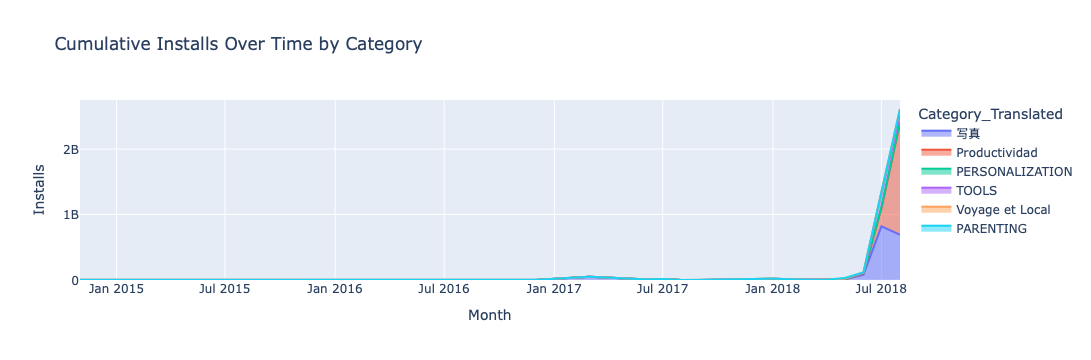

In [52]:
fig = px.area(
    area_data,
    x='Month',
    y='Installs',
    color='Category_Translated',
    title="Cumulative Installs Over Time by Category"
)
fig.show()

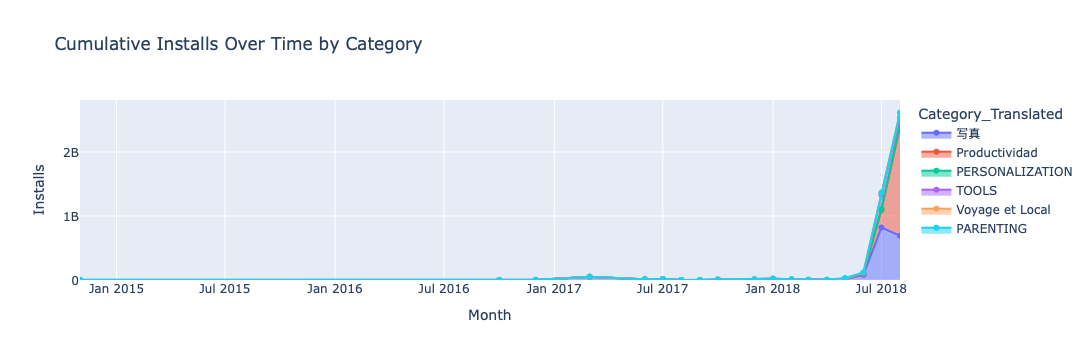

In [53]:
fig.update_traces(mode="lines+markers")

In [54]:
fig.write_html("task4_stacked_area_chart.html")

In [55]:
print(area_data.head(10))

       Month Category_Translated  Installs  MoM_Growth  High_Growth
0 2014-11-01                  写真   1000000         NaN        False
1 2016-10-01       Productividad   1000000         NaN        False
2 2016-12-01     PERSONALIZATION   2000000         NaN        False
3 2017-03-01                  写真  50000000   49.000000         True
4 2017-06-01                  写真  10000000   -0.800000        False
5 2017-07-01                  写真  15000000    0.500000         True
6 2017-08-01               TOOLS     50000         NaN        False
7 2017-09-01     PERSONALIZATION   1000000   -0.500000        False
8 2017-10-01     Voyage et Local     50000         NaN        False
9 2017-10-01                  写真   5000000   -0.666667        False


task 5


In [56]:
df_task5 = final_df[(final_df['Rating'] >= 4.0)&(final_df['Size_MB'] >= 10)&(final_df['Last Updated'].dt.month == 1)]
print("Filtered Shape:", df_task5.shape)

Filtered Shape: (131, 20)


In [57]:
top10_categories = (df_task5.groupby('Category')['Installs'].sum().reset_index().nlargest(10, 'Installs'))
print(top10_categories)

           Category   Installs
7            FAMILY  182494820
19           SPORTS  120511000
10             GAME  115691000
5     ENTERTAINMENT   51000000
14  PERSONALIZATION   15060000
15      PHOTOGRAPHY   10500000
11        LIFESTYLE    5071000
4         EDUCATION    2000000
17         SHOPPING    2000000
20            TOOLS    1010000


In [58]:
bar_data = (df_task5[df_task5['Category'].isin(top10_categories['Category'])].groupby('Category').agg({'Rating': 'mean','Reviews': 'sum'}).reset_index())

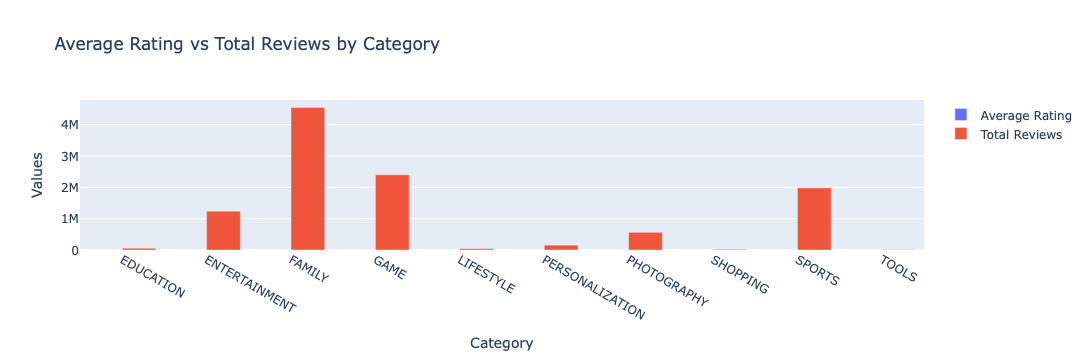

In [59]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Bar(
    x=bar_data['Category'],
    y=bar_data['Rating'],
    name='Average Rating'
))
fig.add_trace(go.Bar(
    x=bar_data['Category'],
    y=bar_data['Reviews'],
    name='Total Reviews'
))
fig.update_layout(
    barmode='group',
    title="Average Rating vs Total Reviews by Category",
    xaxis_title="Category",
    yaxis_title="Values"
)
fig.show()

In [60]:
fig.write_html("task5_grouped_bar_chart.html")

In [61]:
df_task6 = final_df[
    (final_df['Installs'] > 10000) &
    (final_df['Revenue'] > 10000) &
    (final_df['Android Ver'] > 4.0) &
    (final_df['Size_MB'] > 15) &
    (final_df['Content Rating'] == 'Everyone') &
    (final_df['App'].str.len() <= 30)
]

print("Filtered Shape:", df_task6.shape)


Filtered Shape: (21, 20)


In [62]:
top3_categories = (
    df_task6.groupby('Category')['Installs']
    .sum()
    .reset_index()
    .nlargest(3, 'Installs')
)

print(top3_categories)

          Category  Installs
4      PHOTOGRAPHY   3000000
1           FAMILY   2650000
3  PERSONALIZATION   2000000


In [63]:
df_task6 = df_task6[
    df_task6['Category'].isin(top3_categories['Category'])
]

In [64]:
dual_data = (
    df_task6.groupby('Type')
    .agg({
        'Installs': 'mean',
        'Revenue': 'sum'
    })
    .reset_index()
)

print(dual_data)

   Type  Installs     Revenue
0  Paid  765000.0  25373500.0


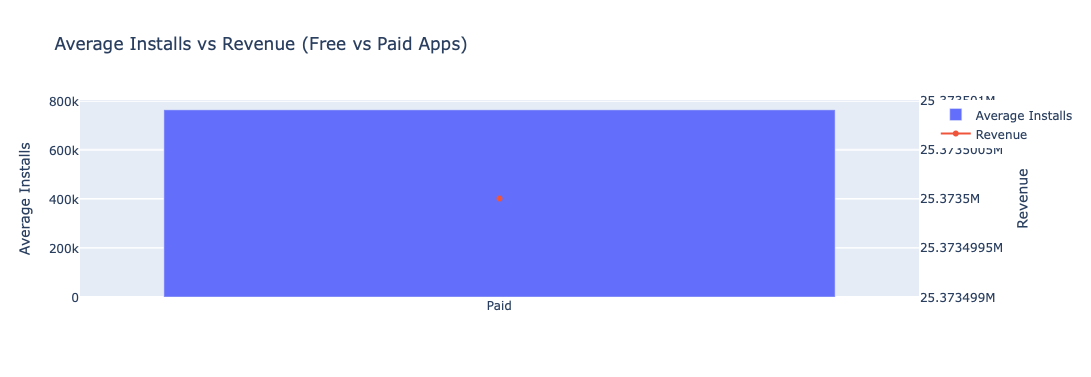

In [66]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Bar(
    x=dual_data['Type'],
    y=dual_data['Installs'],
    name='Average Installs',
    yaxis='y1'
))
fig.add_trace(go.Scatter(
    x=dual_data['Type'],
    y=dual_data['Revenue'],
    name='Revenue',
    yaxis='y2',
    mode='lines+markers'
))
fig.update_layout(
    title="Average Installs vs Revenue (Free vs Paid Apps)",
    
    yaxis=dict(
        title="Average Installs"
    ),
    
    yaxis2=dict(
        title="Revenue",
        overlaying='y',
        side='right'
    )
)
fig.show()

In [67]:
fig.write_html("task6_dual_axis_chart.html")

In [68]:
with open("dashboard.html", "w") as f:
    f.write("PASTE YOUR HTML CODE HERE")